# 군집분석

비슷한 관측값끼리 묶는(군집화) 방식의 분석 방법을 군집분석(Clustering)이라고 일컫는다.

정답이 없는 데이터에서 서로 비슷한 관측값끼리 묶는 방식을 사용한다. 군집분석은 비지도학습(Unsupervised Learning)이기 때문이다.

군집분석은 비지도학습이기 때문에 정답이 없다. 군집이 얼마나 뚜렷하게 나뉘는가와 사람이 해석하고 사용할수 있는가로 품질을 평가해볼 수 있다.


- 입항 유형을 나눌 수 있을까?
- 자주 오는 배는 어떤 그룹인가?
- 부두마다 어떤 성격?
- 비슷한 하루가 반복되나?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')


In [3]:
list("ABCEDFGHIJKL")

['A', 'B', 'C', 'E', 'D', 'F', 'G', 'H', 'I', 'J', 'K', 'L']

In [5]:
toy = pd.DataFrame({
    "선박": list("ABCDEFGHIJKL"),
    "총톤수": [55, 62, 48, 70, 0.3, 0.2, 0.4, 0.3, 0.5, 0.3, 0.6, 0.4],
    "체류시간": [22, 26, 20, 30, 5, 4, 6, 3, 90, 110, 100, 95],
    "화물": [30, 41, 25, 52, 0, 0, 0, 0, 0, 0, 0, 0],
})

toy

,선박,총톤수,체류시간,화물
0,A,55.0,22,30
1,B,62.0,26,41
2,C,48.0,20,25
3,D,70.0,30,52
4,E,0.3,5,0
5,F,0.2,4,0
6,G,0.4,6,0
7,H,0.3,3,0
8,I,0.5,90,0
9,J,0.3,110,0


In [6]:
toy['군집'] = ['대형 하역'] * 4 + ['소형 단기'] * 4 + ['소형 대기'] * 4

toy

,선박,총톤수,체류시간,화물,군집
0,A,55.0,22,30,대형 하역
1,B,62.0,26,41,대형 하역
2,C,48.0,20,25,대형 하역
3,D,70.0,30,52,대형 하역
4,E,0.3,5,0,소형 단기
5,F,0.2,4,0,소형 단기
6,G,0.4,6,0,소형 단기
7,H,0.3,3,0,소형 단기
8,I,0.5,90,0,소형 대기
9,J,0.3,110,0,소형 대기


C:\Users\user\AppData\Local\Temp\ipykernel_6960\3348314692.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


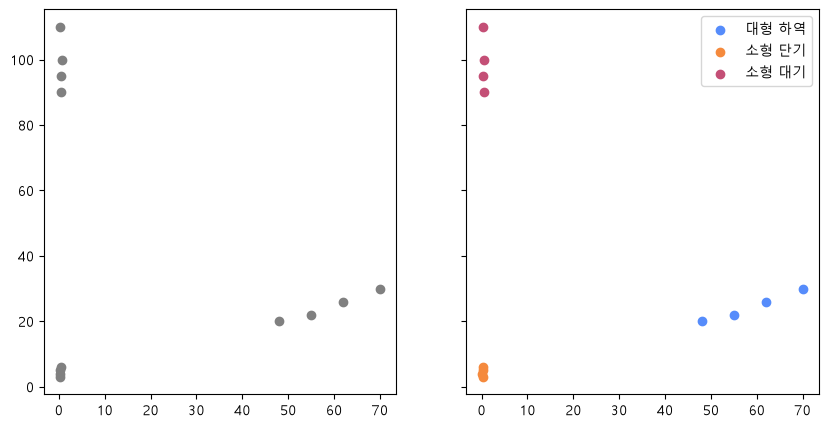

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

axes[0].scatter(toy['총톤수'], toy['체류시간'], color='gray')

for group, part  in toy.groupby('군집'):
    axes[1].scatter(part['총톤수'], part['체류시간'], label=group)

axes[1].legend()

fig.show()